In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import joblib
import os

##### ==============================================================================
##### 1. DATA LOADING AND PREPROCESSING
##### ==============================================================================

In [2]:
# Load data
df = pd.read_csv('bank_transactions.csv')
print(f"Original data shape: {df.shape}")
print(df.head())

Original data shape: (1048567, 9)
  TransactionID CustomerID CustomerDOB CustGender CustLocation  \
0            T1   C5841053     10/1/94          F   JAMSHEDPUR   
1            T2   C2142763      4/4/57          M      JHAJJAR   
2            T3   C4417068    26/11/96          F       MUMBAI   
3            T4   C5342380     14/9/73          F       MUMBAI   
4            T5   C9031234     24/3/88          F  NAVI MUMBAI   

   CustAccountBalance TransactionDate  TransactionTime  \
0            17819.05          2/8/16           143207   
1             2270.69          2/8/16           141858   
2            17874.44          2/8/16           142712   
3           866503.21          2/8/16           142714   
4             6714.43          2/8/16           181156   

   TransactionAmount (INR)  
0                     25.0  
1                  27999.0  
2                    459.0  
3                   2060.0  
4                   1762.5  


In [3]:
# Parse dates with correct format
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], format='%d/%m/%y', errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d/%m/%y', errors='coerce')

In [4]:
# Fix year issue (dates after 2000 should be 1900s)
def fix_year(dob):
    if pd.isna(dob):
        return dob
    year = dob.year
    if year >= 2000:
        return dob.replace(year=year - 100)
    return dob

df['CustomerDOB'] = df['CustomerDOB'].apply(fix_year)

In [5]:
# Create Age feature
df['Age'] = df['TransactionDate'].dt.year - df['CustomerDOB'].dt.year

In [6]:
# Extract TransactionHour
df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = df['TransactionTime'].str[:2].astype(int)

In [7]:
# Handle missing values
df.dropna(subset=['CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance'], inplace=True)
print(f"After removing nulls: {df.shape}")

After removing nulls: (985322, 11)


In [8]:
# Label encode gender
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['CustGender'])

In [9]:
# Top locations mapping
top_locations = df['CustLocation'].value_counts().head(30).index
df['Location_clean'] = df['CustLocation'].apply(lambda x: x if x in top_locations else 'OTHER')
le_loc = LabelEncoder()
df['Location_enc'] = le_loc.fit_transform(df['Location_clean'])

In [10]:
# Create balance change feature
df['balance_change'] = df['CustAccountBalance'] - df['TransactionAmount (INR)']

In [11]:
# Create High Value Transaction Flag
df['HighValueTransaction'] = df['TransactionAmount (INR)'] > 10000

In [12]:
print("\nData preprocessing completed!")
print(df.info())


Data preprocessing completed!
<class 'pandas.core.frame.DataFrame'>
Index: 985322 entries, 0 to 1048566
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   TransactionID            985322 non-null  object        
 1   CustomerID               985322 non-null  object        
 2   CustomerDOB              985322 non-null  datetime64[ns]
 3   CustGender               985322 non-null  object        
 4   CustLocation             985322 non-null  object        
 5   CustAccountBalance       985322 non-null  float64       
 6   TransactionDate          985322 non-null  datetime64[ns]
 7   TransactionTime          985322 non-null  object        
 8   TransactionAmount (INR)  985322 non-null  float64       
 9   Age                      985322 non-null  float64       
 10  TransactionHour          985322 non-null  int32         
 11  Gender_enc               985322 non-null  int32    

##### ==============================================================================
##### 2. CUSTOMER AGGREGATION (RFM STYLE)
##### ==============================================================================

In [13]:
max_date = df['TransactionDate'].max()

In [14]:
customer_agg = df.groupby('CustomerID').agg(
    FirstTransaction=('TransactionDate', 'min'),
    LastTransaction=('TransactionDate', 'max'),
    Frequency=('TransactionDate', 'count'),
    Monetary_sum=('TransactionAmount (INR)', 'sum'),
    Monetary_mean=('TransactionAmount (INR)', 'mean'),
    Monetary_std=('TransactionAmount (INR)', 'std'),
    AvgBalance=('CustAccountBalance', 'mean'),
    Age=('Age', 'first'),
    Gender=('Gender_enc', 'first'),
    LocationEnc=('Location_enc', 'first'),
    AvgTime=('TransactionHour', 'mean'),
    NumLocations=('CustLocation', lambda x: x.nunique())
).reset_index()

In [15]:
customer_agg['Recency_days'] = (max_date - customer_agg['LastTransaction']).dt.days
customer_agg['Monetary_std'] = customer_agg['Monetary_std'].fillna(0)

In [16]:
print(f"\nCustomer aggregation shape: {customer_agg.shape}")
print(customer_agg.head())


Customer aggregation shape: (839081, 14)
  CustomerID FirstTransaction LastTransaction  Frequency  Monetary_sum  \
0   C1010011       2016-08-09      2016-09-26          2        5106.0   
1   C1010012       2016-08-14      2016-08-14          1        1499.0   
2   C1010014       2016-08-01      2016-08-07          2        1455.0   
3   C1010018       2016-09-15      2016-09-15          1          30.0   
4   C1010024       2016-08-18      2016-08-18          1        5000.0   

   Monetary_mean  Monetary_std  AvgBalance   Age  Gender  LocationEnc  \
0         2553.0   3107.027197   76340.635  24.0       0           24   
1         1499.0      0.000000   24204.490  22.0       1           19   
2          727.5    675.286976  100112.950  24.0       0           19   
3           30.0      0.000000     496.180  26.0       0           25   
4         5000.0      0.000000   87058.650  51.0       1           15   

   AvgTime  NumLocations  Recency_days  
0      6.5             2         

In [17]:
print("\n" + "="*80)
print("FRAUD DETECTION")
print("="*80)


FRAUD DETECTION


In [18]:
# Select features for fraud detection
features_fraud = [
    'TransactionAmount (INR)', 
    'CustAccountBalance', 
    'Age',
    'TransactionHour', 
    'Gender_enc', 
    'Location_enc'
]

X_fraud = df[features_fraud]

In [19]:
# Train Isolation Forest
iso_forest = IsolationForest(
    contamination=0.01, 
    random_state=42, 
    n_jobs=-1
)
df['Fraud_Anomaly'] = iso_forest.fit_predict(X_fraud)

In [20]:
# Report results
frauds = (df['Fraud_Anomaly'] == -1).sum()
print(f"\nDetected {frauds:,} potential frauds ({frauds/len(df)*100:.3f}%)")


Detected 9,854 potential frauds (1.000%)


In [21]:
# Feature importance for fraud detection
print("\nCalculating fraud detection feature importance...")
sample_size = min(8000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)
X_sample = X_fraud.iloc[sample_indices]
y_sample = df['Fraud_Anomaly'].iloc[sample_indices]

perm = permutation_importance(
    iso_forest, 
    X_sample, 
    y_sample,
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)


Calculating fraud detection feature importance...


Feature importance plot saved as 'fraud_feature_importance.png'


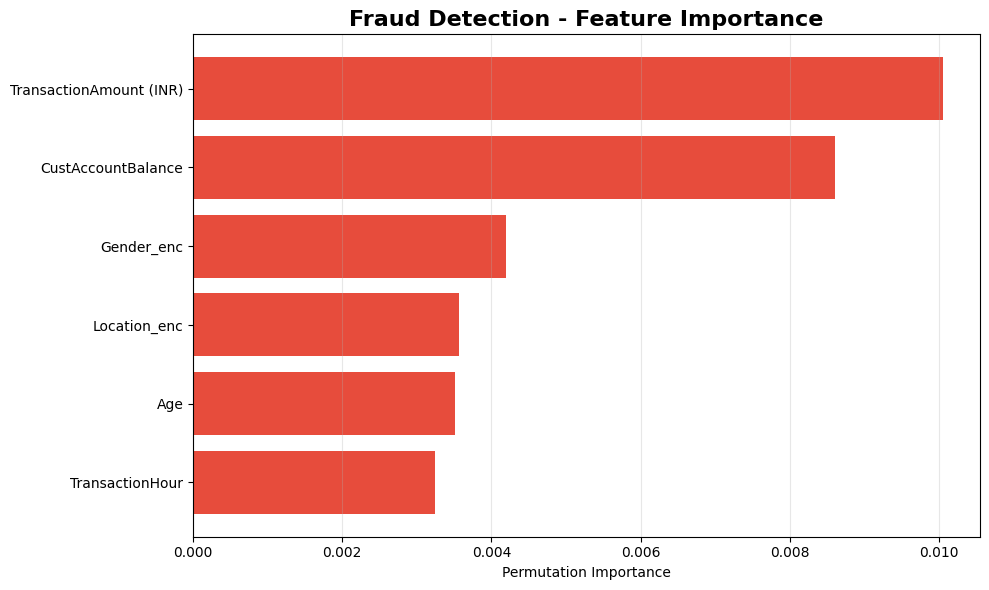

In [22]:
# Plot feature importance
sorted_idx = perm.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(
    np.array(features_fraud)[sorted_idx], 
    perm.importances_mean[sorted_idx], 
    color='#e74c3c'
)
plt.title('Fraud Detection - Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Permutation Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_feature_importance.png', dpi=300, bbox_inches='tight')
print("Feature importance plot saved as 'fraud_feature_importance.png'")

In [23]:
# Top suspicious transactions
print("\nTop 10 Suspicious Transactions:")
suspicious = df[df['Fraud_Anomaly'] == -1].nlargest(10, 'TransactionAmount (INR)')[
    ['CustomerID', 'TransactionDate', 'TransactionAmount (INR)', 
     'CustAccountBalance', 'CustLocation']
]
print(suspicious)


Top 10 Suspicious Transactions:
       CustomerID TransactionDate  TransactionAmount (INR)  \
399117   C7319271      2016-08-18               1560034.99   
579014   C6677159      2016-08-22               1380002.88   
532036   C4141768      2016-08-23                991132.22   
749353   C8217728      2016-09-02                724122.00   
56540    C1830891      2016-08-03                720001.16   
846924   C6549785      2016-09-09                600008.32   
173291   C5036642      2016-08-04                600003.45   
356306   C4328064      2016-08-14                569500.27   
152735   C1425138      2016-08-05                561001.00   
777251   C7549492      2016-09-06                543699.36   

        CustAccountBalance CustLocation  
399117            42487.89      GURGAON  
579014            98660.33         PUNE  
532036            83608.10    NEW DELHI  
749353         61382213.47       MUMBAI  
56540             14177.65      KOLKATA  
846924            29198.46      

In [24]:
# Save fraud detection model
os.makedirs('mod', exist_ok=True)
joblib.dump(iso_forest, 'mod/fraud_detection_model.pkl')
print("\nFraud detection model saved to 'mod/fraud_detection_model.pkl'")


Fraud detection model saved to 'mod/fraud_detection_model.pkl'


In [25]:
print("\n" + "="*80)
print("CHURN PREDICTION")
print("="*80)


CHURN PREDICTION


In [26]:
# Create churn features
customer_features = customer_agg.copy()

In [27]:
# Additional features
customer_features['low_balance'] = customer_features['Monetary_mean'] < customer_features['Monetary_mean'].median()
customer_features['low_frequency'] = customer_features['Frequency'] < customer_features['Frequency'].quantile(0.25)
customer_features['high_value_dormant'] = (
    (customer_features['Monetary_sum'] > customer_features['Monetary_sum'].quantile(0.75)) &
    (customer_features['Recency_days'] > 30)
)

In [28]:
# Create churn label
customer_features['churn_label'] = (
    (customer_features['Recency_days'] > 90) |
    ((customer_features['Recency_days'] > 60) & customer_features['low_frequency']) |
    ((customer_features['Recency_days'] > 30) & customer_features['low_balance']) |
    (customer_features['high_value_dormant'])
).astype(int)

print("\nChurn Label Distribution:")
print(customer_features['churn_label'].value_counts())
print(customer_features['churn_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Churn Label Distribution:
churn_label
1    597450
0    241631
Name: count, dtype: int64
churn_label
1    71.2%
0    28.8%
Name: proportion, dtype: object


In [29]:
# RFM Segmentation
customer_features['R_quartile'] = pd.qcut(
    customer_features['Recency_days'] + 0.0001, 
    4, 
    labels=[4, 3, 2, 1], 
    duplicates='drop'
)
customer_features['F_quartile'] = pd.qcut(
    customer_features['Frequency'].rank(method='first'), 
    4, 
    labels=[1, 2, 3, 4]
)
customer_features['M_quartile'] = pd.qcut(
    customer_features['Monetary_mean'], 
    4, 
    labels=[1, 2, 3, 4]
)

customer_features['RFM_Score'] = (
    customer_features['R_quartile'].astype(str) + 
    customer_features['F_quartile'].astype(str) + 
    customer_features['M_quartile'].astype(str)
)

In [30]:
# RFM Categories
def rfm_category(score):
    if score in ['444', '443', '434', '344']:
        return 'Champions'
    elif score.startswith('3') or score.startswith('4'):
        return 'Loyal'
    elif score.startswith('2'):
        return 'At Risk'
    elif score.startswith('1'):
        return 'Hibernating'
    else:
        return 'Needs Attention'

customer_features['RFM_Category'] = customer_features['RFM_Score'].apply(rfm_category)
print("\nRFM Category Distribution:")
print(customer_features['RFM_Category'].value_counts())


RFM Category Distribution:
RFM_Category
Loyal          359273
Hibernating    208434
At Risk        203120
Champions       68254
Name: count, dtype: int64


In [31]:
# Prepare features for model training
# Convert datetime columns to numeric
customer_features['FirstTransactionDays'] = (max_date - customer_features['FirstTransaction']).dt.days
customer_features['LastTransactionDays'] = (max_date - customer_features['LastTransaction']).dt.days

In [32]:
# Select numeric features for modeling
feature_cols = [
    'Frequency', 'Monetary_sum', 'Monetary_mean', 'Monetary_std',
    'AvgBalance', 'Age', 'Gender', 'LocationEnc', 'AvgTime',
    'NumLocations', 'Recency_days', 'FirstTransactionDays', 'LastTransactionDays'
]

X = customer_features[feature_cols]
y = customer_features['churn_label']

In [33]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Train XGBoost model
print("\nTraining churn prediction model...")
churn_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

churn_model.fit(X_train_scaled, y_train)


Training churn prediction model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [36]:
# Evaluate model
y_pred = churn_model.predict(X_test_scaled)
y_pred_prob = churn_model.predict_proba(X_test_scaled)[:, 1]

print("\nChurn Prediction Model Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")


Churn Prediction Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     48326
           1       1.00      1.00      1.00    119491

    accuracy                           1.00    167817
   macro avg       1.00      1.00      1.00    167817
weighted avg       1.00      1.00      1.00    167817

ROC-AUC Score: 1.0000


In [37]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': churn_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features for Churn Prediction:")
print(feature_importance.head(10))


Top 10 Features for Churn Prediction:
                 feature  importance
1           Monetary_sum    0.438534
2          Monetary_mean    0.420701
10          Recency_days    0.139422
0              Frequency    0.000254
3           Monetary_std    0.000173
4             AvgBalance    0.000167
8                AvgTime    0.000156
5                    Age    0.000132
11  FirstTransactionDays    0.000126
7            LocationEnc    0.000122



Feature importance plot saved as 'churn_feature_importance.png'


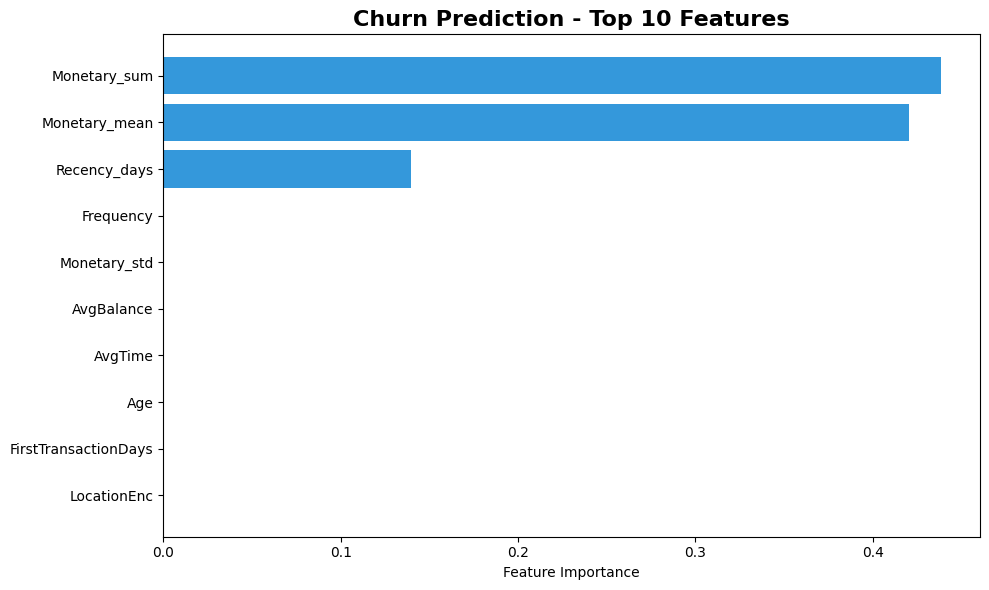

In [38]:
# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'], color='#3498db')
plt.xlabel('Feature Importance')
plt.title('Churn Prediction - Top 10 Features', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=300, bbox_inches='tight')
print("\nFeature importance plot saved as 'churn_feature_importance.png'")

In [39]:
# Add churn probability to customer features
X_all_scaled = scaler.transform(customer_features[feature_cols])
customer_features['Churn_Probability'] = churn_model.predict_proba(X_all_scaled)[:, 1]

# Identify high-risk customers
high_risk_threshold = 0.5
high_risk_customers = customer_features[
    customer_features['Churn_Probability'] > high_risk_threshold
]

print(f"\nNumber of high-risk customers (prob > {high_risk_threshold}): {len(high_risk_customers):,}")
print(f"Percentage of customer base: {len(high_risk_customers)/len(customer_features)*100:.2f}%")


Number of high-risk customers (prob > 0.5): 597,642
Percentage of customer base: 71.23%


In [40]:
# Save models and data
joblib.dump(churn_model, 'mod/churn_prediction_model.pkl')
joblib.dump(scaler, 'mod/churn_scaler.pkl')
customer_features.to_csv('customer_features_with_predictions.csv', index=False)

print("\nChurn prediction model saved to 'mod/churn_prediction_model.pkl'")
print("Customer features with predictions saved to 'customer_features_with_predictions.csv'")


Churn prediction model saved to 'mod/churn_prediction_model.pkl'
Customer features with predictions saved to 'customer_features_with_predictions.csv'


In [41]:
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)


ANALYSIS SUMMARY


In [42]:
print(f"\nTotal Customers: {len(customer_features):,}")
print(f"Total Transactions: {len(df):,}")
print(f"Date Range: {df['TransactionDate'].min()} to {df['TransactionDate'].max()}")
print(f"\nFraud Detection:")
print(f"  - Suspicious transactions: {frauds:,} ({frauds/len(df)*100:.3f}%)")
print(f"\nChurn Analysis:")
print(f"  - Churned customers: {customer_features['churn_label'].sum():,}")
print(f"  - Churn rate: {customer_features['churn_label'].mean()*100:.2f}%")
print(f"  - High-risk customers: {len(high_risk_customers):,}")
print(f"\nRFM Segmentation:")
for category in customer_features['RFM_Category'].value_counts().index:
    count = (customer_features['RFM_Category'] == category).sum()
    pct = count / len(customer_features) * 100
    print(f"  - {category}: {count:,} ({pct:.1f}%)")

print("\n" + "="*80)
print("Analysis complete! Check the output files:")
print("  - fraud_feature_importance.png")
print("  - churn_feature_importance.png")
print("  - models/fraud_detection_model.pkl")
print("  - models/churn_prediction_model.pkl")
print("  - customer_features_with_predictions.csv")
print("="*80)


Total Customers: 839,081
Total Transactions: 985,322
Date Range: 2016-08-01 00:00:00 to 2016-10-21 00:00:00

Fraud Detection:
  - Suspicious transactions: 9,854 (1.000%)

Churn Analysis:
  - Churned customers: 597,450
  - Churn rate: 71.20%
  - High-risk customers: 597,642

RFM Segmentation:
  - Loyal: 359,273 (42.8%)
  - Hibernating: 208,434 (24.8%)
  - At Risk: 203,120 (24.2%)
  - Champions: 68,254 (8.1%)

Analysis complete! Check the output files:
  - fraud_feature_importance.png
  - churn_feature_importance.png
  - models/fraud_detection_model.pkl
  - models/churn_prediction_model.pkl
  - customer_features_with_predictions.csv
